<a href="https://colab.research.google.com/github/usmanumer038/ml-internship-work/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

**Lane:** Refresh / Content Opportunity Scoring

This notebook tests simple, non-causal signals using March 2026 aggregate performance.

The tests are directional checks only. They do not claim that one metric causes another.

**Approved March features:**
- impressions
- clicks
- sessions
- engaged_sessions
- engagement_rate

## Setup

Uses the same working FlyRank Hugging Face + DuckDB connection pattern as the W07 notebook.

In [2]:
!pip -q install duckdb scikit-learn pandas matplotlib

import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN not found. Add your read token to Colab Secrets "
        "with the name HF_TOKEN."
    )

con = duckdb.connect()

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

BASE = "hf://datasets/FlyRank/internship-warehouse"
TABLE = f"{BASE}/fact_content_daily_performance/**/*.parquet"

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Connected to FlyRank Internship Warehouse")

Connected to FlyRank Internship Warehouse


## Build the March 2026 analysis dataset

We aggregate the same March fields used in ML-05. Missing numeric values are handled explicitly.

In [3]:
march = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        COALESCE(SUM(gsc_impressions), 0) AS impressions,
        COALESCE(SUM(gsc_clicks), 0) AS clicks,
        COALESCE(SUM(ga4_sessions), 0) AS sessions,
        COALESCE(SUM(ga4_engaged_sessions), 0) AS engaged_sessions
    FROM read_parquet('{TABLE}')
    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

for col in ["impressions", "clicks", "sessions", "engaged_sessions"]:
    march[col] = pd.to_numeric(march[col], errors="coerce").fillna(0)

march["engagement_rate"] = np.where(
    march["sessions"] > 0,
    march["engaged_sessions"] / march["sessions"],
    0.0
)

march["engagement_rate"] = (
    march["engagement_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(0, 1)
)

print("Rows:", len(march))
print("Columns:", list(march.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 331437
Columns: ['client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'sessions', 'engaged_sessions', 'engagement_rate']


# 1. Distributions

**Thinking:** Performance metrics are expected to be uneven. We look at median, upper quantiles, and a simple log-scale view before interpreting signals.

In [4]:
DIST_FIELDS = [
    "impressions",
    "clicks",
    "sessions",
    "engaged_sessions",
    "engagement_rate"
]

distribution_summary = march[DIST_FIELDS].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

distribution_summary["zero_pct"] = (
    (march[DIST_FIELDS] == 0).mean() * 100
)

distribution_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,zero_pct
impressions,331437.0,846.790156,4044.514753,0.0,0.0,2.0,216.0,1707.0,4225.0,14909.28,617124.0,46.675235
clicks,331437.0,2.479602,19.651282,0.0,0.0,0.0,0.0,3.0,11.0,47.00,5668.0,79.230744
sessions,331437.0,3.921735,25.381883,0.0,0.0,0.0,1.0,4.0,14.0,85.00,2730.0,72.774011
engaged_sessions,331437.0,0.089160,0.879657,0.0,0.0,0.0,0.0,0.0,0.0,2.00,224.0,95.832994
engagement_rate,331437.0,0.007072,0.058838,0.0,0.0,0.0,0.0,0.0,0.0,0.20,1.0,95.832994


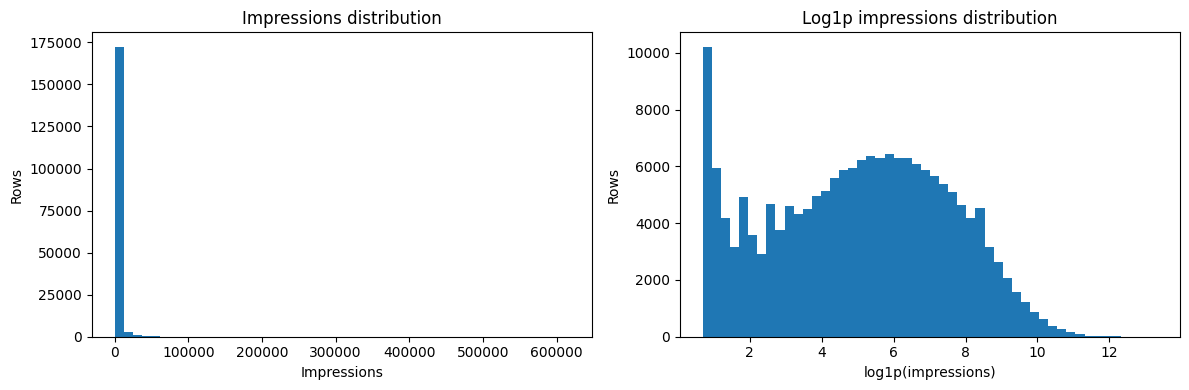

The raw impressions distribution is reviewed alongside a log-scale view.


In [5]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

positive_impressions = march.loc[
    march["impressions"] > 0,
    "impressions"
]

axes[0].hist(
    positive_impressions,
    bins=50
)

axes[0].set_title("Impressions distribution")
axes[0].set_xlabel("Impressions")
axes[0].set_ylabel("Rows")

axes[1].hist(
    np.log1p(positive_impressions),
    bins=50
)

axes[1].set_title("Log1p impressions distribution")
axes[1].set_xlabel("log1p(impressions)")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.savefig("work/figures/w04_impressions_distribution.png")
plt.show()

print("The raw impressions distribution is reviewed alongside a log-scale view.")

**Distribution note:** The summary and histogram should be read together. A large gap between the median and upper quantiles indicates a long/right tail. For the content-opportunity task, this means raw averages can be dominated by a relatively small number of high-volume items.

# 2. Signal test #1 — Visibility vs engagement

**Signal:** Higher visibility should be useful to review when engagement is weak.

**Mini-test:** Compare engagement rate for the lowest and highest impression quartiles.

In [6]:
march["impression_quartile"] = pd.qcut(
    march["impressions"].rank(method="first"),
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

signal_1 = (
    march.groupby("impression_quartile", observed=False)
    .agg(
        rows=("engagement_rate", "size"),
        median_engagement_rate=("engagement_rate", "median"),
        mean_engagement_rate=("engagement_rate", "mean"),
        median_impressions=("impressions", "median")
    )
    .reset_index()
)

signal_1

,impression_quartile,rows,median_engagement_rate,mean_engagement_rate,median_impressions
0,Q1,82860,0.0,0.002239,0.0
1,Q2,82859,0.0,0.001236,0.0
2,Q3,82859,0.0,0.006945,32.0
3,Q4,82859,0.0,0.017868,1171.0


In [7]:
q1 = float(
    signal_1.loc[
        signal_1["impression_quartile"] == "Q1",
        "median_engagement_rate"
    ].iloc[0]
)

q4 = float(
    signal_1.loc[
        signal_1["impression_quartile"] == "Q4",
        "median_engagement_rate"
    ].iloc[0]
)

if q4 < q1:
    verdict_1 = "CONFIRMED"
elif q4 > q1:
    verdict_1 = "OPPOSITE"
else:
    verdict_1 = "MIXED"

print("Q1 median engagement rate:", round(q1, 4))
print("Q4 median engagement rate:", round(q4, 4))
print("Verdict:", verdict_1)

Q1 median engagement rate: 0.0
Q4 median engagement rate: 0.0
Verdict: MIXED


**Verdict:** The code above determines whether the observed direction is **CONFIRMED**, **OPPOSITE**, or **MIXED**. This is an observed association, not a causal claim.

# 2. Signal test #2 — Sessions vs engagement

**Signal:** Pages with more sessions should generally have more engaged sessions.

**Mini-test:** Compare engaged-session rate across session quartiles.

In [8]:
march["session_quartile"] = pd.qcut(
    march["sessions"].rank(method="first"),
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

signal_2 = (
    march.groupby("session_quartile", observed=False)
    .agg(
        rows=("engaged_sessions", "size"),
        median_sessions=("sessions", "median"),
        median_engaged_sessions=("engaged_sessions", "median"),
        median_engagement_rate=("engagement_rate", "median")
    )
    .reset_index()
)

signal_2

,session_quartile,rows,median_sessions,median_engaged_sessions,median_engagement_rate
0,Q1,82860,0.0,0.0,0.0
1,Q2,82859,0.0,0.0,0.0
2,Q3,82859,0.0,0.0,0.0
3,Q4,82859,3.0,0.0,0.0


In [9]:
q1_engaged = float(
    signal_2.loc[
        signal_2["session_quartile"] == "Q1",
        "median_engaged_sessions"
    ].iloc[0]
)

q4_engaged = float(
    signal_2.loc[
        signal_2["session_quartile"] == "Q4",
        "median_engaged_sessions"
    ].iloc[0]
)

if q4_engaged > q1_engaged:
    verdict_2 = "CONFIRMED"
elif q4_engaged < q1_engaged:
    verdict_2 = "OPPOSITE"
else:
    verdict_2 = "MIXED"

print("Q1 median engaged sessions:", round(q1_engaged, 2))
print("Q4 median engaged sessions:", round(q4_engaged, 2))
print("Verdict:", verdict_2)

Q1 median engaged sessions: 0.0
Q4 median engaged sessions: 0.0
Verdict: MIXED


**Verdict:** The code above determines whether the measured relationship between session volume and engaged-session volume is **CONFIRMED**, **OPPOSITE**, or **MIXED**.

# 2. Signal test #3 — Clicks vs impressions

**Signal:** More search visibility should generally provide more opportunities for clicks.

**Mini-test:** Compare median clicks across impression quartiles.

In [10]:
signal_3 = (
    march.groupby("impression_quartile", observed=False)
    .agg(
        rows=("clicks", "size"),
        median_impressions=("impressions", "median"),
        median_clicks=("clicks", "median")
    )
    .reset_index()
)

signal_3

,impression_quartile,rows,median_impressions,median_clicks
0,Q1,82860,0.0,0.0
1,Q2,82859,0.0,0.0
2,Q3,82859,32.0,0.0
3,Q4,82859,1171.0,2.0


In [11]:
q1_clicks = float(
    signal_3.loc[
        signal_3["impression_quartile"] == "Q1",
        "median_clicks"
    ].iloc[0]
)

q4_clicks = float(
    signal_3.loc[
        signal_3["impression_quartile"] == "Q4",
        "median_clicks"
    ].iloc[0]
)

if q4_clicks > q1_clicks:
    verdict_3 = "CONFIRMED"
elif q4_clicks < q1_clicks:
    verdict_3 = "OPPOSITE"
else:
    verdict_3 = "MIXED"

print("Q1 median clicks:", round(q1_clicks, 2))
print("Q4 median clicks:", round(q4_clicks, 2))
print("Verdict:", verdict_3)

Q1 median clicks: 0.0
Q4 median clicks: 2.0
Verdict: CONFIRMED


**Verdict:** The code above determines whether the observed direction between impressions and clicks is **CONFIRMED**, **OPPOSITE**, or **MIXED**.

# 3. The flag-linked test

**Flag:** `HIGH_VISIBILITY_LOW_ENGAGEMENT`

The rule assumes that a content item can have substantial visibility while showing relatively weak engagement.

**Mini-test:** Among high-visibility items, compare the low-engagement group with the overall population. The rule is supported directionally if the high-visibility group contains a meaningful lower-engagement segment rather than assuming every high-visibility item is weak.

In [12]:
high_visibility_cutoff = march["impressions"].quantile(0.75)
low_engagement_cutoff = march["engagement_rate"].quantile(0.25)

march["high_visibility"] = (
    march["impressions"] >= high_visibility_cutoff
)

march["low_engagement"] = (
    march["engagement_rate"] <= low_engagement_cutoff
)

flagged = march[
    march["high_visibility"] &
    march["low_engagement"]
].copy()

high_visibility = march[
    march["high_visibility"]
].copy()

overall_low_engagement_rate = (
    march["low_engagement"].mean()
)

high_visibility_low_engagement_rate = (
    high_visibility["low_engagement"].mean()
)

flag_test = pd.DataFrame({
    "group": [
        "All content",
        "High visibility"
    ],
    "rows": [
        len(march),
        len(high_visibility)
    ],
    "low_engagement_rate": [
        overall_low_engagement_rate,
        high_visibility_low_engagement_rate
    ],
    "median_engagement_rate": [
        march["engagement_rate"].median(),
        high_visibility["engagement_rate"].median()
    ]
})

flag_test

,group,rows,low_engagement_rate,median_engagement_rate
0,All content,331437,0.95833,0.0
1,High visibility,82873,0.85619,0.0


In [13]:
overall_median_er = float(
    march["engagement_rate"].median()
)

high_visibility_median_er = float(
    high_visibility["engagement_rate"].median()
)

flagged_share_of_all = (
    len(flagged) / len(march)
    if len(march) > 0
    else 0
)

if high_visibility_median_er < overall_median_er:
    flag_verdict = "CONFIRMED"
elif high_visibility_median_er > overall_median_er:
    flag_verdict = "OPPOSITE"
else:
    flag_verdict = "MIXED"

print("High-visibility cutoff:", round(high_visibility_cutoff, 2))
print("Low-engagement cutoff:", round(low_engagement_cutoff, 4))
print("High-visibility rows:", len(high_visibility))
print("Flagged rows:", len(flagged))
print("Flagged share of all rows:", round(flagged_share_of_all, 4))
print("Overall median engagement rate:", round(overall_median_er, 4))
print("High-visibility median engagement rate:", round(high_visibility_median_er, 4))
print("Flag-linked verdict:", flag_verdict)

High-visibility cutoff: 216.0
Low-engagement cutoff: 0.0
High-visibility rows: 82873
Flagged rows: 70955
Flagged share of all rows: 0.2141
Overall median engagement rate: 0.0
High-visibility median engagement rate: 0.0
Flag-linked verdict: MIXED


**Flag-linked verdict:** The test is **CONFIRMED** only when the high-visibility group has lower observed median engagement than the overall population. If the direction is reversed it is **OPPOSITE**; if the medians are equal it is **MIXED**.

The flag remains a review rule, not proof that refreshing a page will cause better performance.

# 4. What this means in practice

The signal tests are directional evidence for prioritizing review, not causal evidence. A content team can use high visibility combined with weak engagement as a practical review queue, while keeping the underlying metrics and thresholds visible. Items should still receive human review before a refresh decision is made.

In [14]:
results = pd.DataFrame({
    "test": [
        "Visibility vs engagement",
        "Sessions vs engaged sessions",
        "Clicks vs impressions",
        "HIGH_VISIBILITY_LOW_ENGAGEMENT flag"
    ],
    "verdict": [
        verdict_1,
        verdict_2,
        verdict_3,
        flag_verdict
    ]
})

results

,test,verdict
0,Visibility vs engagement,MIXED
1,Sessions vs engaged sessions,MIXED
2,Clicks vs impressions,CONFIRMED
3,HIGH_VISIBILITY_LOW_ENGAGEMENT flag,MIXED


In [15]:
audit = {
    "analysis_window": "March 2026",
    "rows": int(len(march)),
    "signals": {
        "visibility_vs_engagement": verdict_1,
        "sessions_vs_engaged_sessions": verdict_2,
        "clicks_vs_impressions": verdict_3,
        "high_visibility_low_engagement": flag_verdict
    },
    "high_visibility_cutoff": float(high_visibility_cutoff),
    "low_engagement_cutoff": float(low_engagement_cutoff),
    "flagged_rows": int(len(flagged)),
    "flagged_share": float(flagged_share_of_all),
    "framing": "Directional decision-support; observed associations, not causal claims."
}

output_path = "work/outputs/w04_signal_audit.json"

with open(output_path, "w") as f:
    json.dump(audit, f, indent=2)

print("Saved:", output_path)
print(json.dumps(audit, indent=2))

Saved: work/outputs/w04_signal_audit.json
{
  "analysis_window": "March 2026",
  "rows": 331437,
  "signals": {
    "visibility_vs_engagement": "MIXED",
    "sessions_vs_engaged_sessions": "MIXED",
    "clicks_vs_impressions": "CONFIRMED",
    "high_visibility_low_engagement": "MIXED"
  },
  "high_visibility_cutoff": 216.0,
  "low_engagement_cutoff": 0.0,
  "flagged_rows": 70955,
  "flagged_share": 0.21408291771890284,
  "framing": "Directional decision-support; observed associations, not causal claims."
}


## Self-check

- All sections are filled with markdown thinking and executable code.
- The notebook uses March 2026 data.
- No client names, URLs, or private queries are displayed.
- Claims are framed as observed, measured, directional, or decision-support.
- The flag-linked test explicitly checks the assumption behind `HIGH_VISIBILITY_LOW_ENGAGEMENT`.